In [124]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [125]:
# descarga de datos
df_btc = yf.download('BTC-USD', period='5y', interval='1d')

# limpieza
df_btc.columns = df_btc.columns.get_level_values(0)
df_btc.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [126]:
# calculamos retorno
df_btc['Return'] = df_btc['Close'].pct_change() * 100
df_btc.dropna(inplace=True)

# calculo desviacion estandar
std_dev = df_btc['Return'].std()

# calculamos el sesgo
skew = df_btc['Return'].skew()

# calculamos curtuosis
kurt = df_btc['Return'].kurt()

# calculo de percentiles
percentile_25 = df_btc['Return'].quantile(0.25)
percentile_50 = df_btc['Return'].quantile(0.5)
percentile_75 = df_btc['Return'].quantile(0.75)

print(f'Standar deviation: {std_dev}')
print(f'Skewness:          {skew}')
print(f'Kurtosis:          {kurt} \n')
print(f'25th Percentile:   {percentile_25}')
print(f'50th Percentile:   {percentile_50}')
print(f'75th Percentile:   {percentile_75} \n')

df_btc.index = pd.to_datetime(df_btc.index)

semestral_stats = df_btc.groupby(pd.Grouper(freq='6ME'))['Return'].agg(['std', 'skew', 'kurt', 'mean'])
print('\nSemestral stats: ')
print(semestral_stats)

yearly_stats = df_btc.groupby(df_btc.index.year)['Return'].agg(['std', 'skew', 'kurt', 'mean'])
print('\nYearly stats:')
print(yearly_stats)

Standar deviation: 2.939517168708932
Skewness:          -0.002297046264401139
Kurtosis:          3.673124969551491 

25th Percentile:   -1.2985785439463216
50th Percentile:   -0.0254114125752547
75th Percentile:   1.381899292127986 


Semestral stats: 
                 std      skew      kurt      mean
Date                                              
2021-04-30  4.632126  1.149212  1.494663 -0.359543
2021-10-31  4.258293 -0.231340  1.079066  0.123535
2022-04-30  3.254394  0.382579  3.022856 -0.215681
2022-10-31  3.407976 -0.636429  3.451808 -0.271931
2023-04-30  2.888058 -0.052045  5.659147  0.238605
2023-10-31  1.961889  0.890378  5.517036  0.110974
2024-04-30  2.846910  0.069694  1.384068  0.347837
2024-10-31  2.569242  0.744750  2.833551  0.112168
2025-04-30  2.797059  0.473419  1.928746  0.201075
2025-10-31  1.744070  0.004260  1.893869  0.097187
2026-04-30  2.712562 -0.097855  6.163143 -0.189877

Yearly stats:
           std      skew      kurt      mean
Date                    

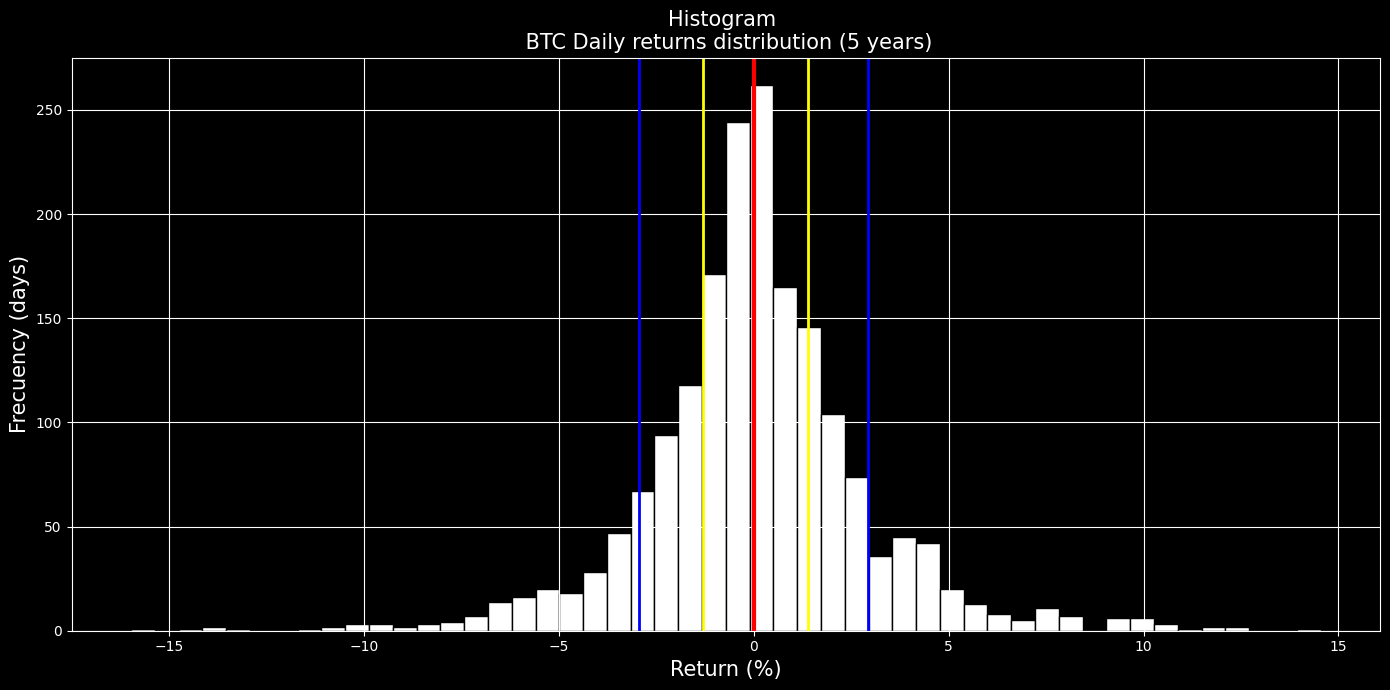

In [127]:
# histograma
plt.figure(figsize=(14, 7))
plt.hist(df_btc['Return'], bins=50, color='white', edgecolor='black')
plt.style.use('dark_background')
plt.axvline(0, color='red', linestyle='-', linewidth=3) # marco el centro

plt.axvline(std_dev, color='blue', linestyle='-', linewidth=2)
plt.axvline(-std_dev, color='blue', linestyle='-', linewidth=2)

plt.axvline(percentile_25, color='yellow', linestyle='-', linewidth=2)
plt.axvline(percentile_75, color='yellow', linestyle='-', linewidth=2)

plt.title('Histogram \n BTC Daily returns distribution (5 years)', fontsize=15)
plt.xlabel('Return (%)', fontsize=15)
plt.ylabel('Frecuency (days)', fontsize=15)

plt.grid(True)
plt.tight_layout()
plt.show()

In [128]:
# columna de signal
df_btc['Signal'] = df_btc['Return'] < (-std_dev)*1.5

# cantidad de signals generadas
signal_count = df_btc['Signal'].sum()

# probabilidad de que se active
signal_probability = (signal_count / len(df_btc) * 100)

# mocer hacia atras un lugar
df_btc['Tomorrow_return'] = df_btc['Return'].shift(-1)
df_btc.dropna(inplace=True)

# variable para ver los dias de signal
only_signs = df_btc[df_btc['Signal'] == True]

# promedio del dia despues de signal
post_signal_mean = only_signs['Tomorrow_return'].dropna().mean()

# promedio normal diario
normal_mean = df_btc['Return'].dropna().mean()

# retorno minimo y maximo
min = df_btc['Tomorrow_return'].min()
max = df_btc['Tomorrow_return'].max()

# cantidad de ganadoras
winners = (only_signs['Tomorrow_return'] > 0).sum()

# win rate
win_rate = (winners / (len(only_signs))) * 100

# promedio ganancias
avg_earnings = only_signs[only_signs['Tomorrow_return'] > 0]['Tomorrow_return'].mean()

# promedio perdidas
avg_losses = only_signs[only_signs['Tomorrow_return'] < 0]['Tomorrow_return'].abs().mean()

# expectancy
expectancy = (0.5 * avg_earnings) - (0.5 * avg_losses)

print(f'Signal count:      {signal_count}')
print(f'Probability:      {signal_probability: .3f}%')
print(f'Post signal mean: {post_signal_mean: .3f}%')
print(f'Normal mean:      {normal_mean: .3f}%')
print(f'Minimun return:   {min: .3f}%')
print(f'Maximun return:   {max: .3f}%')
print(f'Winning times:     {winners}')
print(f'Win rate:         {win_rate: .3f}%')
print(f'Average earnings: {avg_earnings: .3f}%')
print(f'Average losses:   {avg_losses: .3f}%')
print(f'Expectancy:       {expectancy: .3f}%')

Signal count:      98
Probability:       5.367%
Post signal mean:  0.604%
Normal mean:       0.054%
Minimun return:   -15.975%
Maximun return:    14.541%
Winning times:     49
Win rate:          50.000%
Average earnings:  3.460%
Average losses:    2.253%
Expectancy:        0.604%


In [129]:
# aun no conozco estrategias, y considero que mi capacidad de analisis apenas va a empezar
# ya que aun no entiendo algunas cosas, o al menos no del todo. Pero gracias a ver la curtuosis 
# de cada 6 meses y la anual, podemos ver que btc es demasiado cambiante aunque el histograma o 
# los datos de los 5 year indican que si lo es, pero no tan exagerado como se ve en la tabla yearly stats o
# semestral stats, tambien me pude dar cuenta que analizar los datos generales de anios puede darnos una percepcion
# equivocada, ya que en el histograma de todo el tiempo descargado, podemos ver que esta bastante equilibrada
# la campana, con un kurt un poco positivo, pero no tan exagerado como se puede ver en las tablas
# aunque agregue percentiles aun nose bien como usarlos en una estrategia, la estrategia que use
# tampoco es que se me haya ocurrido, es la de un ejercicio anterior(yo no pense en esa estrategia)
# casi que solo copie, y en la linea de la condicion yo le puse eso, pero pues probando, tampoco es como
# que por el analisis